In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


import os
import glob
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ================================
# PATHS
# ================================

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset/Parkinson_dataset.zip"

UNZIP_DIR = "/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here"

MODEL_DIR = os.path.join(SAVE_DIR, "models")
HISTORY_DIR = os.path.join(SAVE_DIR, "history_files")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
CM_DIR = os.path.join(SAVE_DIR, "confusion_matrices")
REPORT_DIR = os.path.join(SAVE_DIR, "reports")
GRADCAM_DIR = os.path.join(SAVE_DIR, "gradcam_heatmaps")

# Root path for ROC and raw Grad-CAM NPZ files
ROOT_OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here"
os.makedirs(ROOT_OUTPUT_DIR, exist_ok=True)

for d in [UNZIP_DIR, SAVE_DIR, MODEL_DIR, HISTORY_DIR, GRAPH_DIR, CM_DIR, REPORT_DIR, GRADCAM_DIR]:
    os.makedirs(d, exist_ok=True)

print("ZIP_PATH:", ZIP_PATH)
print("UNZIP_DIR:", UNZIP_DIR)
print("SAVE_DIR:", SAVE_DIR)
print("ROOT_OUTPUT_DIR:", ROOT_OUTPUT_DIR)

ZIP_PATH: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset/Parkinson_dataset.zip
UNZIP_DIR: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here
SAVE_DIR: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here
ROOT_OUTPUT_DIR: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here


In [4]:
# ================================
# UNZIP DATASET
# ================================

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

expected_extracted_dir = os.path.join(UNZIP_DIR, "Parkinson_dataset")

if not os.path.exists(expected_extracted_dir) or not os.listdir(expected_extracted_dir):
    print(f"Unzipping dataset to {UNZIP_DIR}...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(UNZIP_DIR)
    print("Dataset unzipped to:", UNZIP_DIR)
else:
    print("Dataset already unzipped at:", expected_extracted_dir)

print("\nContents of UNZIP_DIR:")
for item in os.listdir(UNZIP_DIR):
    print(os.path.join(UNZIP_DIR, item))

Unzipping dataset to /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here...
Dataset unzipped to: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here

Contents of UNZIP_DIR:
/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here/Parkinson_dataset


In [5]:
# ================================
# FIND IMAGE FILES
# ================================

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]

all_images = []

for ext in image_extensions:
    all_images.extend(
        glob.glob(os.path.join(expected_extracted_dir, "**", ext), recursive=True)
    )

print("Total images found:", len(all_images))

if len(all_images) == 0:
    raise ValueError("No images found. Check dataset folder structure.")

print("\nSample image paths:")
for p in all_images[:10]:
    print(p)


# ================================
# CREATE DATAFRAME
# ================================

data = []

for img_path in all_images:
    lower_path = img_path.lower()

    if "healthy" in lower_path or "normal" in lower_path or "control" in lower_path:
        label = 0
        data.append([img_path, label])

    elif "parkinson" in lower_path or "pd" in lower_path:
        label = 1
        data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])

print("\nTotal labeled images:", len(df))
print(df.head())

print("\nClass counts:")
print(df["label"].value_counts())

if len(df) == 0:
    raise ValueError("No labeled images found. Folder names should contain healthy/control/normal or parkinson/pd.")

if df["label"].nunique() != 2:
    raise ValueError("Both classes not found. Need Healthy and Parkinson images.")

Total images found: 11120

Sample image paths:
/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_000.png
/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_001.png
/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_002.png
/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_003.png
/content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_dataset_unzip_here/Parkinson_dataset/healthy_dataset/control_p

In [6]:
# ================================
# SPLIT DATASET
# ================================

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain counts:")
print(train_df["label"].value_counts())

print("\nValidation counts:")
print(val_df["label"].value_counts())

print("\nTest counts:")
print(test_df["label"].value_counts())

Train shape: (7784, 2)
Validation shape: (1668, 2)
Test shape: (1668, 2)

Train counts:
label
1    3892
0    3892
Name: count, dtype: int64

Validation counts:
label
0    834
1    834
Name: count, dtype: int64

Test counts:
label
0    834
1    834
Name: count, dtype: int64


In [7]:
# ================================
# IMAGE GENERATORS
# ================================

IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 35

train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 7784 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}


In [8]:
# ================================
# MODEL A: MOBILENETV2 + VGG16 CONCATENATION FUSION
# ================================

def build_mobilenet_vgg16_concat_model(base_trainable=True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    # Branch-specific preprocessing
    mobile_input = layers.Lambda(
        lambda x: mobilenet_preprocess(x),
        name="mobilenetv2_preprocessing"
    )(inputs)

    vgg_input = layers.Lambda(
        lambda x: vgg16_preprocess(x),
        name="vgg16_preprocessing"
    )(inputs)

    # MobileNetV2 backbone
    raw_mobile = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    mobilenet_backbone = keras.Model(
        inputs=raw_mobile.input,
        outputs=raw_mobile.output,
        name="mobilenetv2_backbone"
    )

    mobilenet_backbone.trainable = base_trainable

    # VGG16 backbone
    raw_vgg = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    vgg_backbone = keras.Model(
        inputs=raw_vgg.input,
        outputs=raw_vgg.output,
        name="vgg16_backbone"
    )

    vgg_backbone.trainable = base_trainable

    # Feature maps
    mobile_features = mobilenet_backbone(mobile_input)
    vgg_features = vgg_backbone(vgg_input)

    # Feature vectors
    mobile_vector = layers.GlobalAveragePooling2D(name="mobilenetv2_gap")(mobile_features)
    vgg_vector = layers.GlobalAveragePooling2D(name="vgg16_gap")(vgg_features)

    # Early fusion by concatenation
    fused = layers.Concatenate(name="early_fusion_concatenation")(
        [mobile_vector, vgg_vector]
    )

    x = layers.Dense(512, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="MobileNetV2_VGG16_Early_Fusion_Concatenation"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [9]:
# ================================
# MODEL B: MOBILENETV2 + VGG16 ATTENTION FUSION
# ================================

def build_mobilenet_vgg16_attention_model(base_trainable=True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    # Branch-specific preprocessing
    mobile_input = layers.Lambda(
        lambda x: mobilenet_preprocess(x),
        name="mobilenetv2_preprocessing"
    )(inputs)

    vgg_input = layers.Lambda(
        lambda x: vgg16_preprocess(x),
        name="vgg16_preprocessing"
    )(inputs)

    # MobileNetV2 backbone
    raw_mobile = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    mobilenet_backbone = keras.Model(
        inputs=raw_mobile.input,
        outputs=raw_mobile.output,
        name="mobilenetv2_backbone"
    )

    mobilenet_backbone.trainable = base_trainable

    # VGG16 backbone
    raw_vgg = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    vgg_backbone = keras.Model(
        inputs=raw_vgg.input,
        outputs=raw_vgg.output,
        name="vgg16_backbone"
    )

    vgg_backbone.trainable = base_trainable

    # Feature maps
    mobile_features = mobilenet_backbone(mobile_input)
    vgg_features = vgg_backbone(vgg_input)

    # Feature vectors
    mobile_vector = layers.GlobalAveragePooling2D(name="mobilenetv2_gap")(mobile_features)
    vgg_vector = layers.GlobalAveragePooling2D(name="vgg16_gap")(vgg_features)

    # Project both features to same size
    mobile_projected = layers.Dense(256, activation="relu", name="mobilenetv2_projected")(mobile_vector)
    vgg_projected = layers.Dense(256, activation="relu", name="vgg16_projected")(vgg_vector)

    # Attention input
    combined_features = layers.Concatenate(name="attention_input")(
        [mobile_projected, vgg_projected]
    )

    # Learnable branch attention weights
    attention_weights = layers.Dense(
        2,
        activation="softmax",
        name="branch_attention_weights"
    )(combined_features)

    # Apply attention weights
    weighted_mobile = layers.Lambda(
        lambda x: x[0] * x[1][:, 0:1],
        name="weighted_mobilenetv2_features"
    )([mobile_projected, attention_weights])

    weighted_vgg = layers.Lambda(
        lambda x: x[0] * x[1][:, 1:2],
        name="weighted_vgg16_features"
    )([vgg_projected, attention_weights])

    # Early fusion by attention
    fused = layers.Add(name="early_fusion_attention")(
        [weighted_mobile, weighted_vgg]
    )

    x = layers.Dense(256, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="MobileNetV2_VGG16_Early_Fusion_Attention"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [10]:
# ================================
# GRAPH FUNCTION
# ================================

def plot_training_history(history, model_name):
    hist = history.history
    epochs = range(1, len(hist["accuracy"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["accuracy"], marker="o", label="Train Accuracy")
    plt.plot(epochs, hist["val_accuracy"], marker="o", label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    acc_path = os.path.join(GRAPH_DIR, f"{model_name}_accuracy_vs_epochs.png")
    plt.savefig(acc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", acc_path)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], marker="o", label="Train Loss")
    plt.plot(epochs, hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{model_name} - Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    loss_path = os.path.join(GRAPH_DIR, f"{model_name}_loss_vs_epochs.png")
    plt.savefig(loss_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", loss_path)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["auc"], marker="o", label="Train AUC")
    plt.plot(epochs, hist["val_auc"], marker="o", label="Validation AUC")
    plt.title(f"{model_name} - AUC vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True)

    auc_path = os.path.join(GRAPH_DIR, f"{model_name}_auc_vs_epochs.png")
    plt.savefig(auc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", auc_path)

In [11]:
# ================================
# EVALUATION FUNCTION
# ================================

def evaluate_model(model, test_gen, model_name):
    test_gen.reset()

    y_prob = model.predict(test_gen).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print("\n==============================")
    print(model_name)
    print("==============================")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC AUC:", auc)

    report = classification_report(
        y_true,
        y_pred,
        target_names=["Healthy", "Parkinson"]
    )

    print("\nClassification Report:")
    print(report)

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    report_path = os.path.join(REPORT_DIR, f"{model_name}_classification_report.txt")

    with open(report_path, "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Accuracy: {acc}\n")
        f.write(f"F1 Score: {f1}\n")
        f.write(f"ROC AUC: {auc}\n\n")
        f.write("Classification Report:\n")
        f.write(report)
        f.write("\nConfusion Matrix:\n")
        f.write(str(cm))

    print("Report saved:", report_path)

    cm_df = pd.DataFrame(
        cm,
        index=["Actual Healthy", "Actual Parkinson"],
        columns=["Predicted Healthy", "Predicted Parkinson"]
    )

    cm_csv_path = os.path.join(CM_DIR, f"{model_name}_confusion_matrix.csv")
    cm_df.to_csv(cm_csv_path)
    print("Confusion matrix CSV saved:", cm_csv_path)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Parkinson"]
    )
    disp.plot(values_format="d", ax=ax)
    plt.title(f"{model_name} - Confusion Matrix")

    cm_png_path = os.path.join(CM_DIR, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Confusion matrix image saved:", cm_png_path)

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)

    roc_path = os.path.join(GRAPH_DIR, f"{model_name}_roc_curve.png")
    plt.savefig(roc_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("ROC curve saved:", roc_path)

    return {
        "model_name": model_name,
        "accuracy": acc,
        "f1_score": f1,
        "roc_auc": auc
    }

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "MobileNetV2_VGG16_Early_Fusion_Concatenation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_backbo… │ (None, 7, 7,      │  2,257,984 │ mobilenetv2_prep… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_gap     │ (None, 1280)      │          0 │ mobilenetv2_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_conca… │ (None, 1792)      │          0 │ mobilenetv2_gap[… │
│ (Concatenate)       │                   │            │ vgg16_gap[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    918,016 │ early_fusion_con… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,058,625 (68.89 MB)

 Trainable params: 18,022,721 (68.75 MB)

 Non-trainable params: 35,904 (140.25 KB)

Epoch 1/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5137 - auc: 0.5171 - loss: 0.9742
Epoch 1: val_auc improved from None to 0.47326, saving model to /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/models/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/models/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_best.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 249s 169ms/step - accuracy: 0.5239 - auc: 0.5311 - loss: 0.9360 - val_accuracy: 0.4820 - val_auc: 0.4733 - val_loss: 0.9252 - learning_rate: 1.0000e-05
Epoch 2/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5232 - auc: 0.5415 - loss: 0.9124
Epoch 2: val_auc improved from 0.47326 to 0.60556, saving model to /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/models/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_b

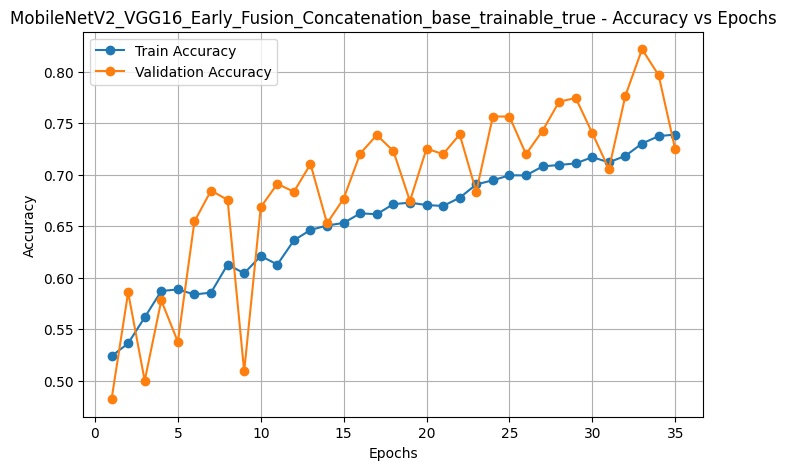

Saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_accuracy_vs_epochs.png


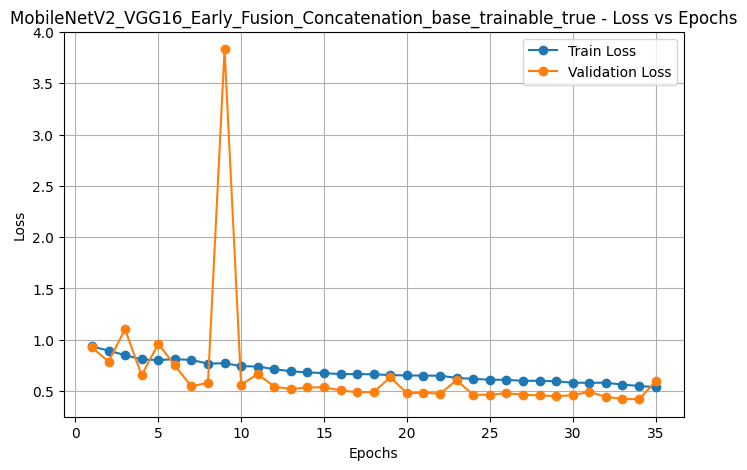

Saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_loss_vs_epochs.png


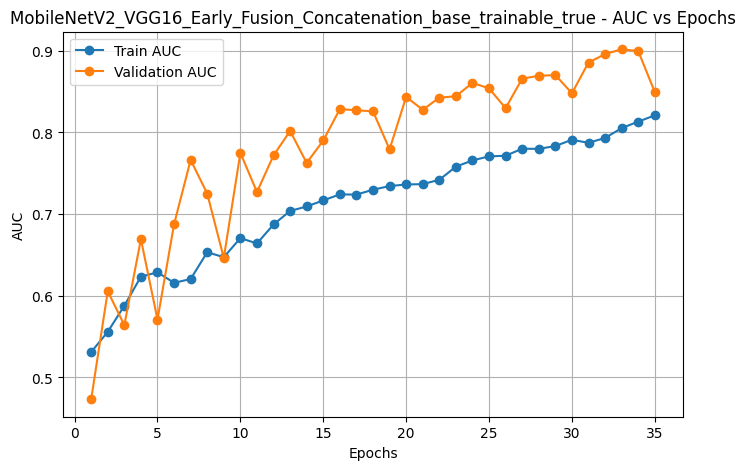

Saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_auc_vs_epochs.png
209/209 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true
Accuracy: 0.8183453237410072
F1 Score: 0.8160291438979964
ROC AUC: 0.8982770618037944

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.81      0.83      0.82       834
   Parkinson       0.83      0.81      0.82       834

    accuracy                           0.82      1668
   macro avg       0.82      0.82      0.82      1668
weighted avg       0.82      0.82      0.82      1668


Confusion Matrix:
[[693 141]
 [162 672]]
Report saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/reports/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_classification_report.txt
Confusion matrix CSV saved: /content/drive/MyDrive/Colab Noteb

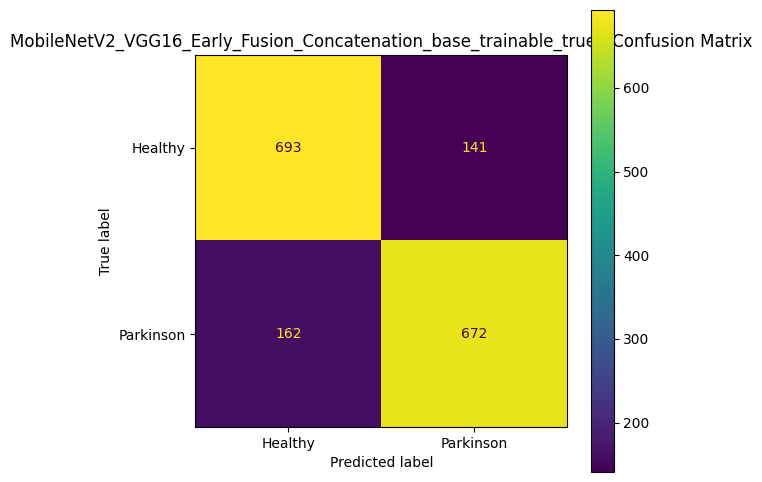

Confusion matrix image saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/confusion_matrices/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_confusion_matrix.png


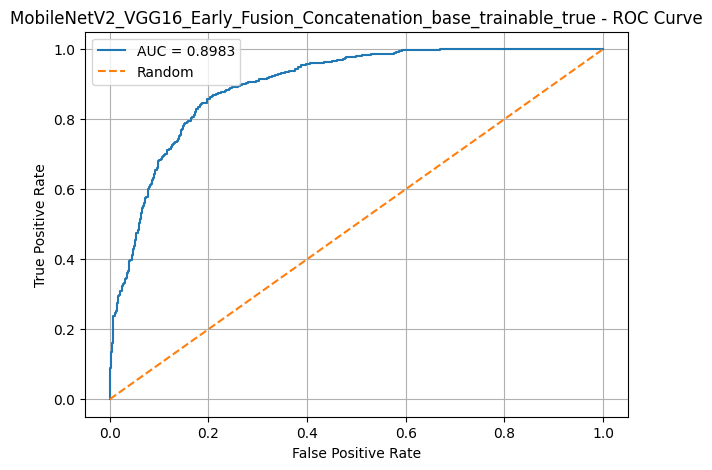

ROC curve saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs/MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_roc_curve.png


In [12]:
# ================================
# TRAIN MODEL A: CONCATENATION FUSION
# ================================

model_name_concat = "MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true"

concat_model = build_mobilenet_vgg16_concat_model(base_trainable=True)

concat_model.summary()

callbacks_concat = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, f"{model_name_concat}_best.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(HISTORY_DIR, f"{model_name_concat}_training_log.csv")
    )
]

history_concat = concat_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_concat
)

concat_final_path = os.path.join(MODEL_DIR, f"{model_name_concat}_final.keras")
concat_model.save(concat_final_path)
print("Final model saved:", concat_final_path)

history_concat_path = os.path.join(HISTORY_DIR, f"{model_name_concat}_history.json")

with open(history_concat_path, "w") as f:
    json.dump(history_concat.history, f)

print("History saved:", history_concat_path)

plot_training_history(history_concat, model_name_concat)

results_concat = evaluate_model(concat_model, test_gen, model_name_concat)

Model: "MobileNetV2_VGG16_Early_Fusion_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_backbo… │ (None, 7, 7,      │  2,257,984 │ mobilenetv2_prep… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_gap     │ (None, 1280)      │          0 │ mobilenetv2_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_projec… │ (None, 256)       │    327,936 │ mobilenetv2_gap[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_projected     │ (None, 256)       │    131,328 │ vgg16_gap[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_input     │ (None, 512)       │          0 │ mobilenetv2_proj… │
│ (Concatenate)       │                   │            │ vgg16_projected[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_attention_w… │ (None, 2)         │      1,026 │ attention_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_mobilenet… │ (None, 256)       │          0 │ mobilenetv2_proj… │
│ (Lambda)            │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_vgg16_fea… │ (None, 256)       │          0 │ vgg16_projected[… │
│ (Lambda)            │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_atten… │ (None, 256)       │          0 │ weighted_mobilen… │
│ (Add)               │                   │            │ weighted_vgg16_f… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ early_fusion_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 17,533,315 (66.88 MB)

 Trainable params: 17,498,435 (66.75 MB)

 Non-trainable params: 34,880 (136.25 KB)

Epoch 1/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5461 - auc: 0.5631 - loss: 0.9001
Epoch 1: val_auc improved from None to 0.64310, saving model to /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/models/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/models/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_best.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 176s 119ms/step - accuracy: 0.5817 - auc: 0.6116 - loss: 0.8379 - val_accuracy: 0.5923 - val_auc: 0.6431 - val_loss: 0.7609 - learning_rate: 1.0000e-05
Epoch 2/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6330 - auc: 0.6857 - loss: 0.7482
Epoch 2: val_auc improved from 0.64310 to 0.68269, saving model to /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/models/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_best.keras

E

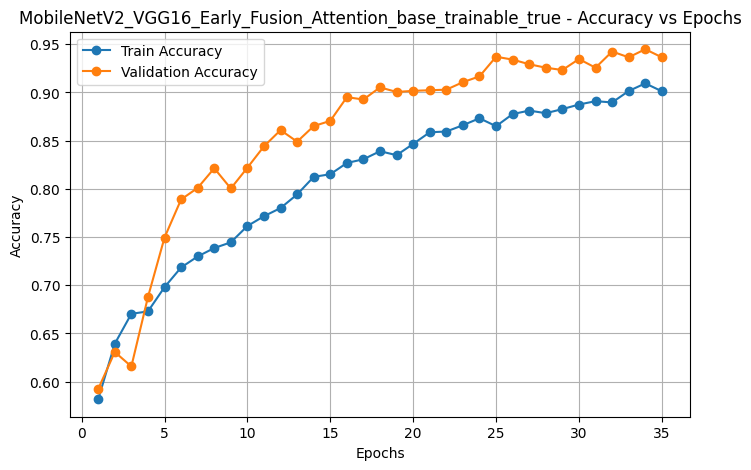

Saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_accuracy_vs_epochs.png


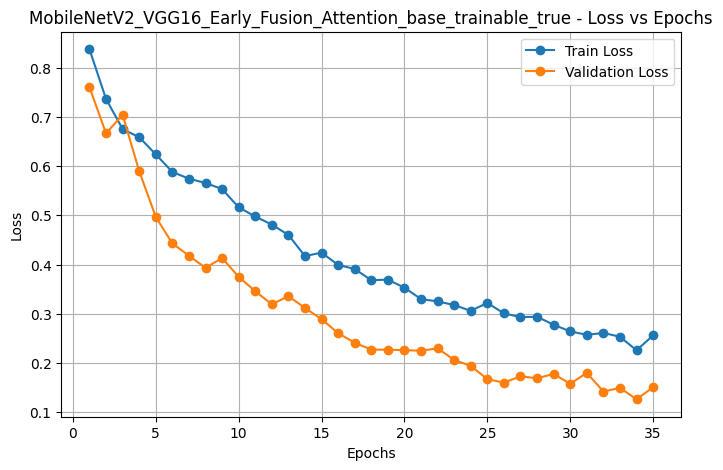

Saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_loss_vs_epochs.png


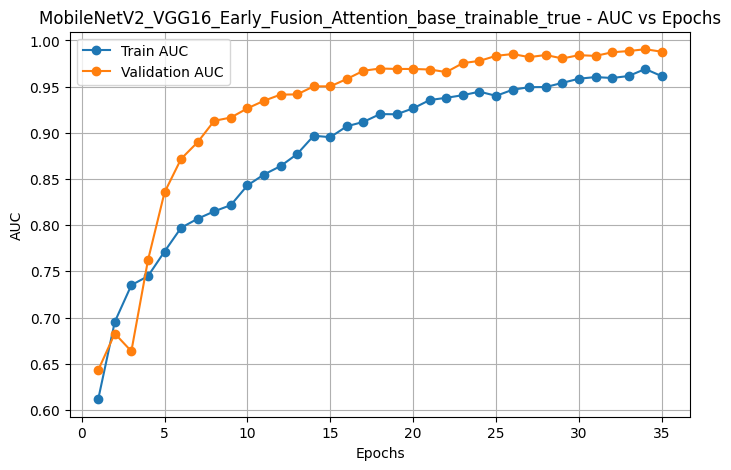

Saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_auc_vs_epochs.png
209/209 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true
Accuracy: 0.9622302158273381
F1 Score: 0.9627439384979303
ROC AUC: 0.9931148606294821

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.95      0.96       834
   Parkinson       0.95      0.98      0.96       834

    accuracy                           0.96      1668
   macro avg       0.96      0.96      0.96      1668
weighted avg       0.96      0.96      0.96      1668


Confusion Matrix:
[[791  43]
 [ 20 814]]
Report saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/reports/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_classification_report.txt
Confusion matrix CSV saved: /content/drive/MyDrive/Colab Notebooks/Mobilen

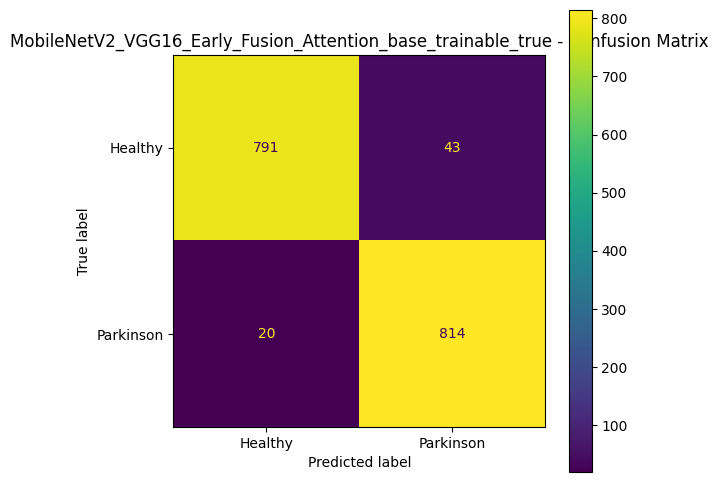

Confusion matrix image saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/confusion_matrices/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_confusion_matrix.png


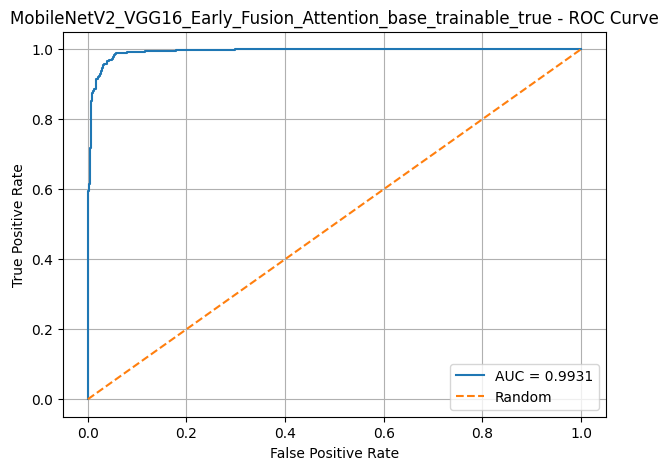

ROC curve saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs/MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_roc_curve.png


In [13]:
# ================================
# TRAIN MODEL B: ATTENTION FUSION
# ================================

model_name_attention = "MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true"

attention_model = build_mobilenet_vgg16_attention_model(base_trainable=True)

attention_model.summary()

callbacks_attention = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, f"{model_name_attention}_best.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(HISTORY_DIR, f"{model_name_attention}_training_log.csv")
    )
]

history_attention = attention_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_attention
)

attention_final_path = os.path.join(MODEL_DIR, f"{model_name_attention}_final.keras")
attention_model.save(attention_final_path)
print("Final model saved:", attention_final_path)

history_attention_path = os.path.join(HISTORY_DIR, f"{model_name_attention}_history.json")

with open(history_attention_path, "w") as f:
    json.dump(history_attention.history, f)

print("History saved:", history_attention_path)

plot_training_history(history_attention, model_name_attention)

results_attention = evaluate_model(attention_model, test_gen, model_name_attention)

In [14]:
# ================================
# COMPARE BOTH FUSION MODELS
# ================================

fusion_comparison_df = pd.DataFrame([
    {
        "Model": results_concat["model_name"],
        "Fusion Method": "Concatenation",
        "Backbones": "MobileNetV2 + VGG16",
        "include_top": False,
        "base_trainable": True,
        "Accuracy": results_concat["accuracy"],
        "F1 Score": results_concat["f1_score"],
        "ROC AUC": results_concat["roc_auc"]
    },
    {
        "Model": results_attention["model_name"],
        "Fusion Method": "Attention",
        "Backbones": "MobileNetV2 + VGG16",
        "include_top": False,
        "base_trainable": True,
        "Accuracy": results_attention["accuracy"],
        "F1 Score": results_attention["f1_score"],
        "ROC AUC": results_attention["roc_auc"]
    }
])

comparison_path = os.path.join(REPORT_DIR, "mobilenetv2_vgg16_early_fusion_comparison.csv")
fusion_comparison_df.to_csv(comparison_path, index=False)

print("Comparison saved:", comparison_path)
fusion_comparison_df

Comparison saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/reports/mobilenetv2_vgg16_early_fusion_comparison.csv


,Model,Fusion Method,Backbones,include_top,base_trainable,Accuracy,F1 Score,ROC AUC
0,MobileNetV2_VGG16_Early_Fusion_Concatenation_b...,Concatenation,MobileNetV2 + VGG16,False,True,0.818345,0.816029,0.898277
1,MobileNetV2_VGG16_Early_Fusion_Attention_base_...,Attention,MobileNetV2 + VGG16,False,True,0.962230,0.962744,0.993115


In [15]:
# ================================
# SAVE ROC DATA AS NPZ
# ================================
# This cell saves probability outputs for both fusion models.
# Run it after the two models have been trained and evaluated.

def save_roc_npz(model, test_generator, filename):
    test_generator.reset()

    y_prob = model.predict(
        test_generator,
        verbose=1
    ).reshape(-1).astype(np.float32)

    y_true = np.asarray(
        test_generator.classes
    ).reshape(-1).astype(np.int32)

    if len(y_true) != len(y_prob):
        raise ValueError(
            f"Length mismatch: y_true={len(y_true)}, "
            f"y_prob={len(y_prob)}"
        )

    if not np.all(np.isfinite(y_prob)):
        raise ValueError(
            "y_prob contains NaN or infinite values."
        )

    if np.any(y_prob < 0.0) or np.any(y_prob > 1.0):
        raise ValueError(
            "y_prob must contain probabilities between 0 and 1."
        )

    if not set(np.unique(y_true).tolist()).issubset({0, 1}):
        raise ValueError(
            f"Expected binary labels 0 and 1, found "
            f"{np.unique(y_true).tolist()}"
        )

    save_path = os.path.join(
        ROOT_OUTPUT_DIR,
        filename
    )

    # Save exactly the two arrays needed for combined ROC plotting.
    np.savez_compressed(
        save_path,
        y_true=y_true,
        y_prob=y_prob
    )

    # Reload immediately to verify the file.
    check = np.load(save_path)

    if set(check.files) != {"y_true", "y_prob"}:
        raise ValueError(
            f"Incorrect NPZ keys: {check.files}"
        )

    if check["y_true"].shape != check["y_prob"].shape:
        raise ValueError(
            "Saved y_true and y_prob shapes do not match."
        )

    print("\nROC NPZ saved successfully")
    print("Path:", save_path)
    print("Keys:", check.files)
    print("y_true shape:", check["y_true"].shape)
    print("y_prob shape:", check["y_prob"].shape)
    print("Unique labels:", np.unique(check["y_true"]))
    print("Minimum probability:", float(check["y_prob"].min()))
    print("Maximum probability:", float(check["y_prob"].max()))
    print("File size:", os.path.getsize(save_path), "bytes")

    return {
        "path": save_path,
        "y_true": y_true,
        "y_prob": y_prob
    }


concat_roc_data = save_roc_npz(
    model=concat_model,
    test_generator=test_gen,
    filename=(
        "vgg16_mobilenet_early_fusion_"
        "concatenation_roc_data.npz"
    )
)

attention_roc_data = save_roc_npz(
    model=attention_model,
    test_generator=test_gen,
    filename=(
        "vgg16_mobilenet_early_fusion_"
        "attention_roc_data.npz"
    )
)

# Select the better model using ROC-AUC, then F1, then accuracy.
if (
    results_concat["roc_auc"],
    results_concat["f1_score"],
    results_concat["accuracy"]
) >= (
    results_attention["roc_auc"],
    results_attention["f1_score"],
    results_attention["accuracy"]
):
    best_fusion_name = "Concatenation"
    best_roc_data = concat_roc_data
else:
    best_fusion_name = "Attention"
    best_roc_data = attention_roc_data

standard_best_npz_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_mobilenet_early_fusion_roc_data.npz"
)

np.savez_compressed(
    standard_best_npz_path,
    y_true=best_roc_data["y_true"],
    y_prob=best_roc_data["y_prob"]
)

standard_check = np.load(
    standard_best_npz_path
)

print("\nBest fusion model:", best_fusion_name)
print("Standard best-model NPZ:", standard_best_npz_path)
print("Keys:", standard_check.files)
print(
    "Shapes:",
    {
        key: standard_check[key].shape
        for key in standard_check.files
    }
)


209/209 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step

ROC NPZ saved successfully
Path: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/vgg16_mobilenet_early_fusion_concatenation_roc_data.npz
Keys: ['y_true', 'y_prob']
y_true shape: (1668,)
y_prob shape: (1668,)
Unique labels: [0 1]
Minimum probability: 6.342025881167501e-05
Maximum probability: 0.9978938698768616
File size: 6962 bytes
209/209 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step

ROC NPZ saved successfully
Path: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/vgg16_mobilenet_early_fusion_attention_roc_data.npz
Keys: ['y_true', 'y_prob']
y_true shape: (1668,)
y_prob shape: (1668,)
Unique labels: [0 1]
Minimum probability: 6.495598654510104e-07
Maximum probability: 0.9999977350234985
File size: 6933 bytes

Best fusion model: Attention
Standard best-model NPZ: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/vgg16_mobilenet_early_fusion_roc_data.npz
Keys: ['y_true', 'y_prob']
Shapes: {'y_

In [16]:
# ================================
# GRAD-CAM FUNCTIONS FOR MOBILENETV2 + VGG16 FUSION MODEL
# ================================

def normalize_heatmap(heatmap):
    heatmap = np.maximum(heatmap, 0)
    max_value = np.max(heatmap)

    if max_value == 0:
        return heatmap

    return heatmap / max_value


def compute_branch_gradcam(model, img_array, branch_name, target_class=None):
    """
    Correct Grad-CAM for MobileNetV2 + VGG16 fusion model.

    branch_name should be:
    - 'mobilenetv2_backbone'
    - 'vgg16_backbone'
    """

    if branch_name == "mobilenetv2_backbone":
        feature_map_tensor = model.get_layer("mobilenetv2_gap").input

    elif branch_name == "vgg16_backbone":
        feature_map_tensor = model.get_layer("vgg16_gap").input

    else:
        raise ValueError(
            "branch_name must be either 'mobilenetv2_backbone' or 'vgg16_backbone'"
        )

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[feature_map_tensor, model.output]
    )

    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(img_array, training=False)

        prob = predictions[:, 0]

        if target_class is None:
            target_class = 1 if prob[0] >= 0.5 else 0

        if target_class == 1:
            class_score = predictions[:, 0]
        else:
            class_score = 1.0 - predictions[:, 0]

    grads = tape.gradient(class_score, feature_maps)

    if grads is None:
        raise ValueError(
            "Gradients are None. Check mobilenetv2_gap and vgg16_gap layer names."
        )

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    feature_maps = feature_maps[0]

    heatmap = feature_maps @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = heatmap.numpy()
    heatmap = normalize_heatmap(heatmap)

    return heatmap, float(prob[0]), target_class


def overlay_heatmap_on_image(original_img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    original_uint8 = np.uint8(original_img)

    overlay = cv2.addWeighted(
        original_uint8,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return overlay, heatmap_resized


def save_fusion_gradcam(model, image_path, model_name, save_prefix):
    img = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array_raw = keras.utils.img_to_array(img)

    # No manual preprocessing here.
    # The model already has MobileNetV2 and VGG16 preprocessing inside it.
    img_array = np.expand_dims(img_array_raw, axis=0).astype("float32")

    pred_prob = model.predict(img_array, verbose=0)[0][0]
    predicted_class = 1 if pred_prob >= 0.5 else 0
    predicted_label = "Parkinson" if predicted_class == 1 else "Healthy"

    mobile_heatmap, _, _ = compute_branch_gradcam(
        model=model,
        img_array=img_array,
        branch_name="mobilenetv2_backbone",
        target_class=predicted_class
    )

    vgg_heatmap, _, _ = compute_branch_gradcam(
        model=model,
        img_array=img_array,
        branch_name="vgg16_backbone",
        target_class=predicted_class
    )

    mobile_overlay, mobile_heatmap_resized = overlay_heatmap_on_image(
        img_array_raw,
        mobile_heatmap
    )

    vgg_overlay, vgg_heatmap_resized = overlay_heatmap_on_image(
        img_array_raw,
        vgg_heatmap
    )

    combined_heatmap = (mobile_heatmap_resized + vgg_heatmap_resized) / 2.0
    combined_heatmap = normalize_heatmap(combined_heatmap)

    combined_overlay, _ = overlay_heatmap_on_image(
        img_array_raw,
        combined_heatmap
    )

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(np.uint8(img_array_raw))
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mobile_overlay)
    plt.title("MobileNetV2 Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(vgg_overlay)
    plt.title("VGG16 Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(combined_overlay)
    plt.title("Combined Grad-CAM")
    plt.axis("off")

    plt.suptitle(
        f"{model_name}\nPrediction: {predicted_label} | Probability: {pred_prob:.4f}",
        fontsize=12
    )

    plt.tight_layout()

    save_path = os.path.join(
        GRADCAM_DIR,
        f"{save_prefix}_{predicted_label}_prob_{pred_prob:.4f}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Grad-CAM saved:", save_path)

    return save_path

Grad-CAM sample images:
                                          image_path label
0  /content/drive/MyDrive/Colab Notebooks/Mobilen...     0
1  /content/drive/MyDrive/Colab Notebooks/Mobilen...     0
2  /content/drive/MyDrive/Colab Notebooks/Mobilen...     0
3  /content/drive/MyDrive/Colab Notebooks/Mobilen...     1
4  /content/drive/MyDrive/Colab Notebooks/Mobilen...     1
5  /content/drive/MyDrive/Colab Notebooks/Mobilen...     1

Generating Grad-CAM for MobileNetV2 + VGG16 Concatenation Fusion Model...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mri_input']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


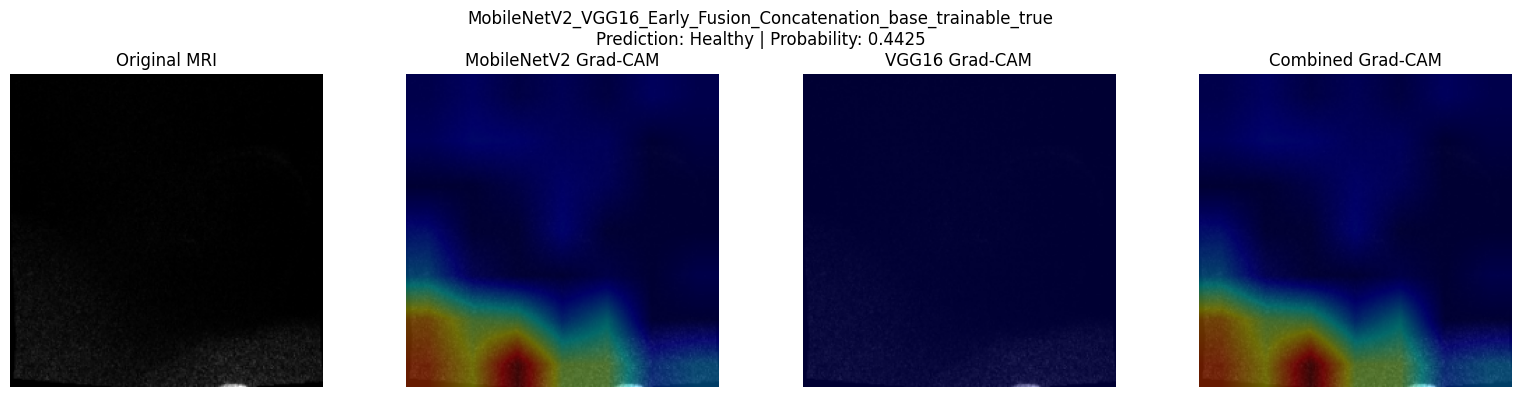

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_concat_sample_0_true_Healthy_Healthy_prob_0.4425.png


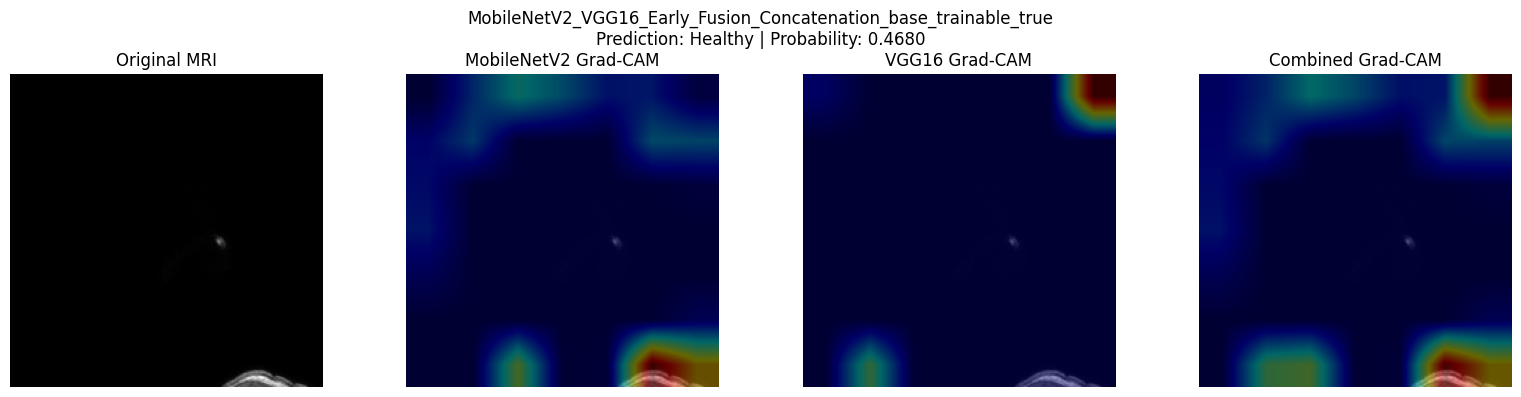

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_concat_sample_1_true_Healthy_Healthy_prob_0.4680.png


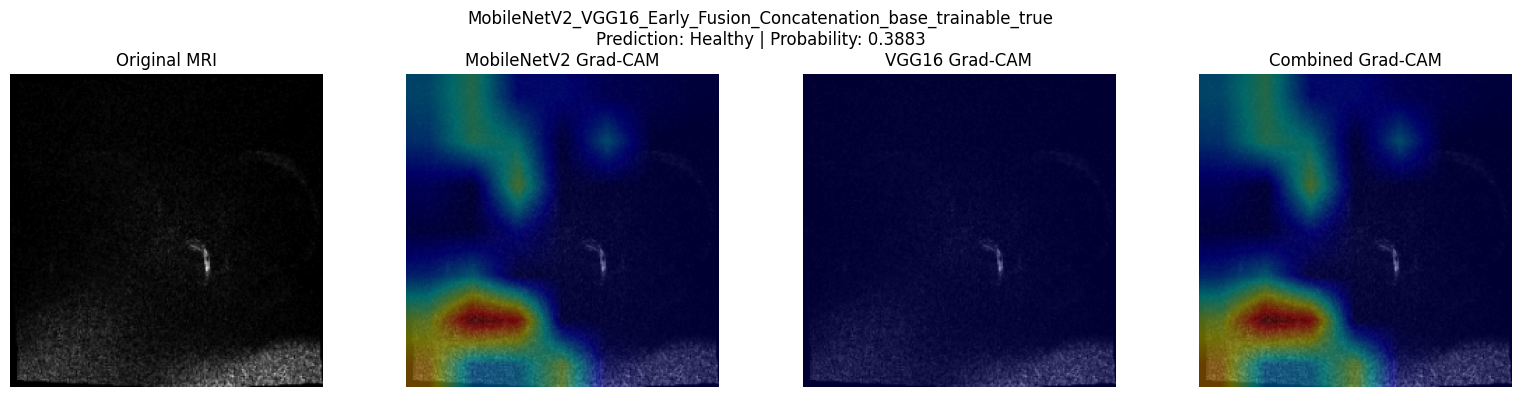

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_concat_sample_2_true_Healthy_Healthy_prob_0.3883.png


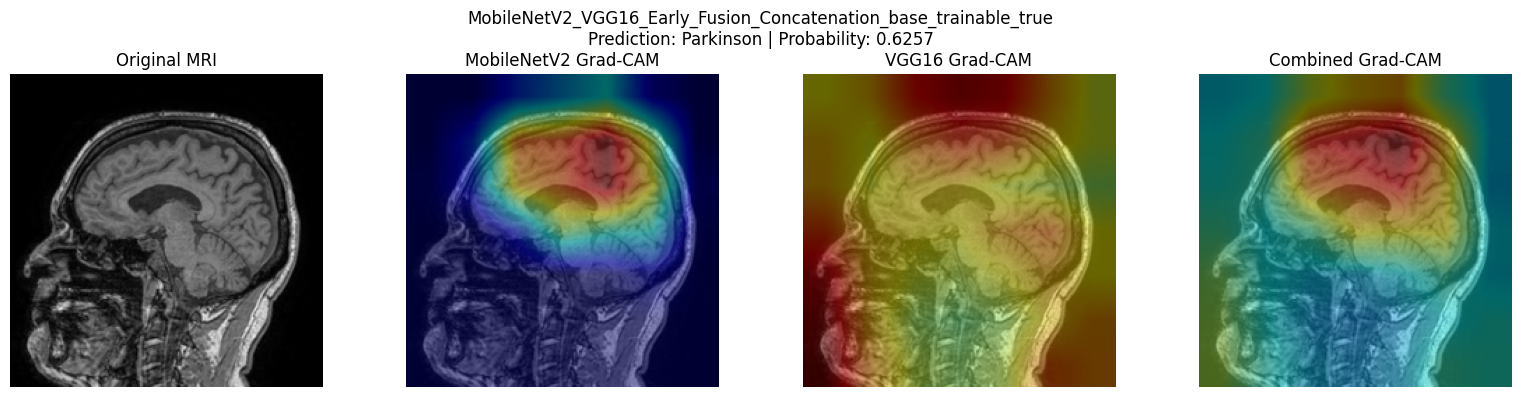

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_concat_sample_3_true_Parkinson_Parkinson_prob_0.6257.png


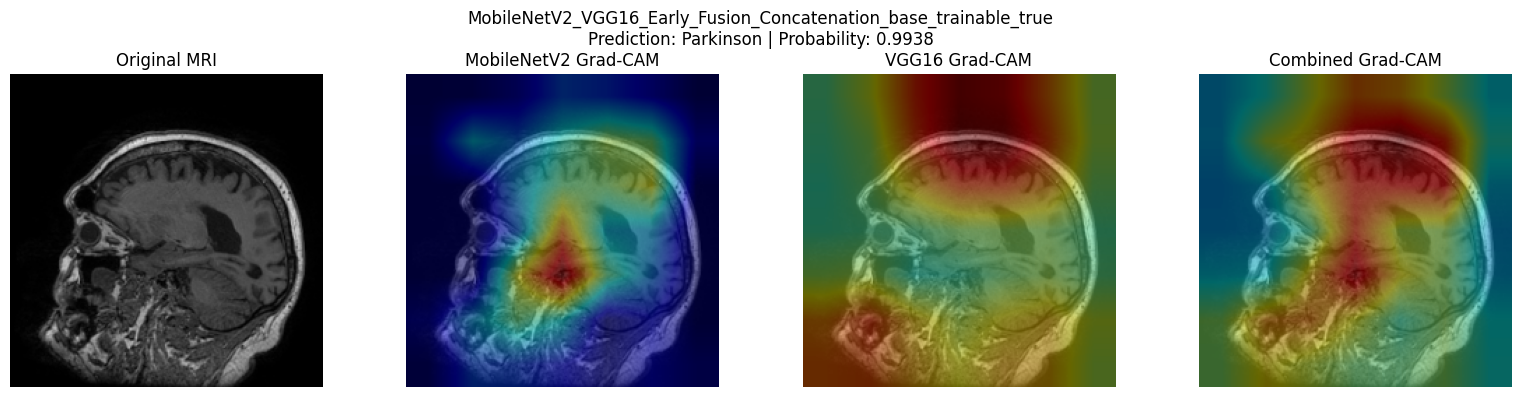

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_concat_sample_4_true_Parkinson_Parkinson_prob_0.9938.png


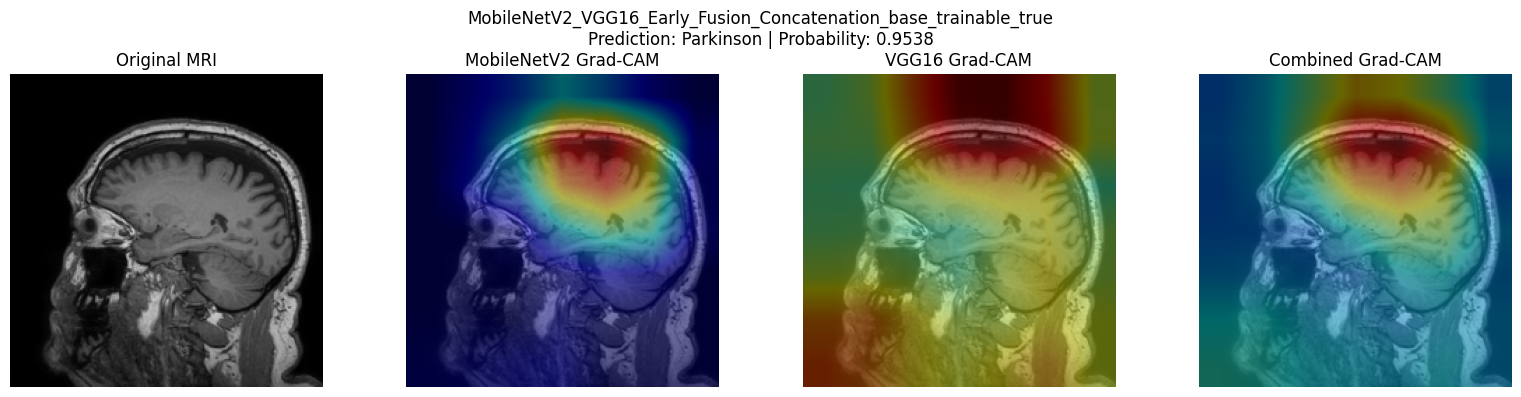

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_concat_sample_5_true_Parkinson_Parkinson_prob_0.9538.png

Generating Grad-CAM for MobileNetV2 + VGG16 Attention Fusion Model...


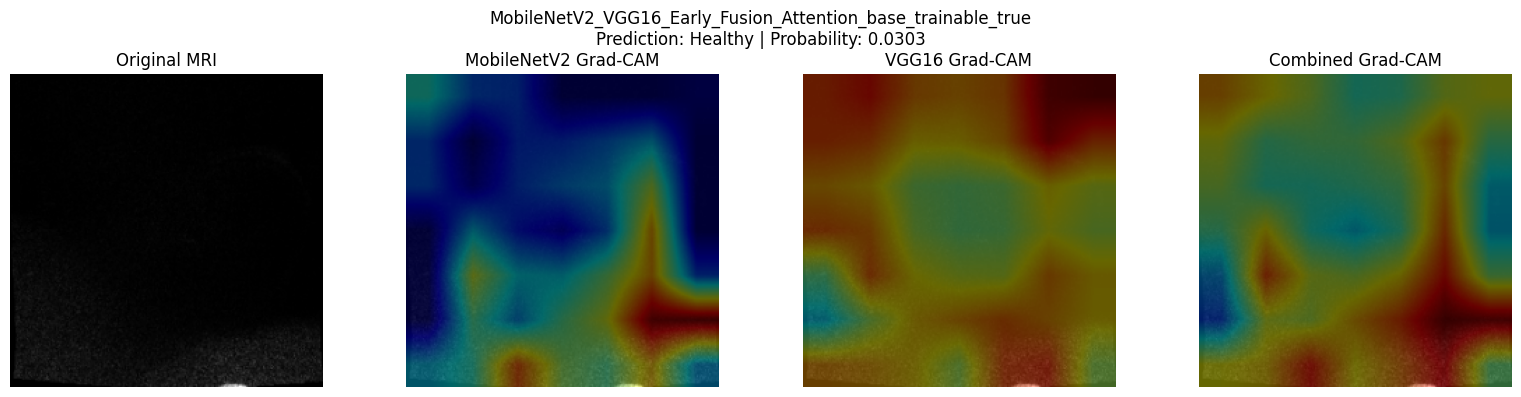

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_attention_sample_0_true_Healthy_Healthy_prob_0.0303.png


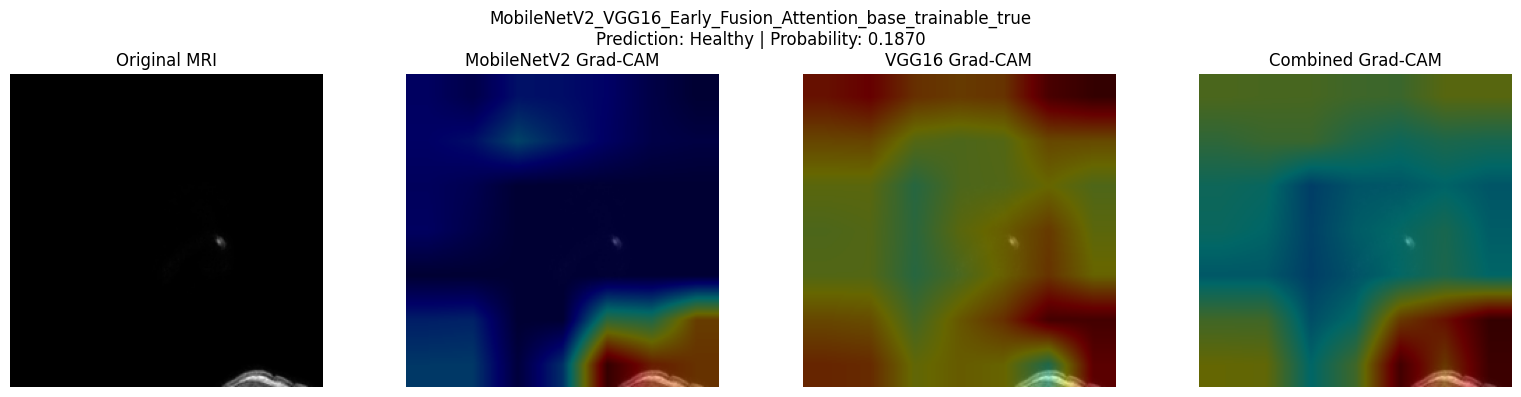

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_attention_sample_1_true_Healthy_Healthy_prob_0.1870.png


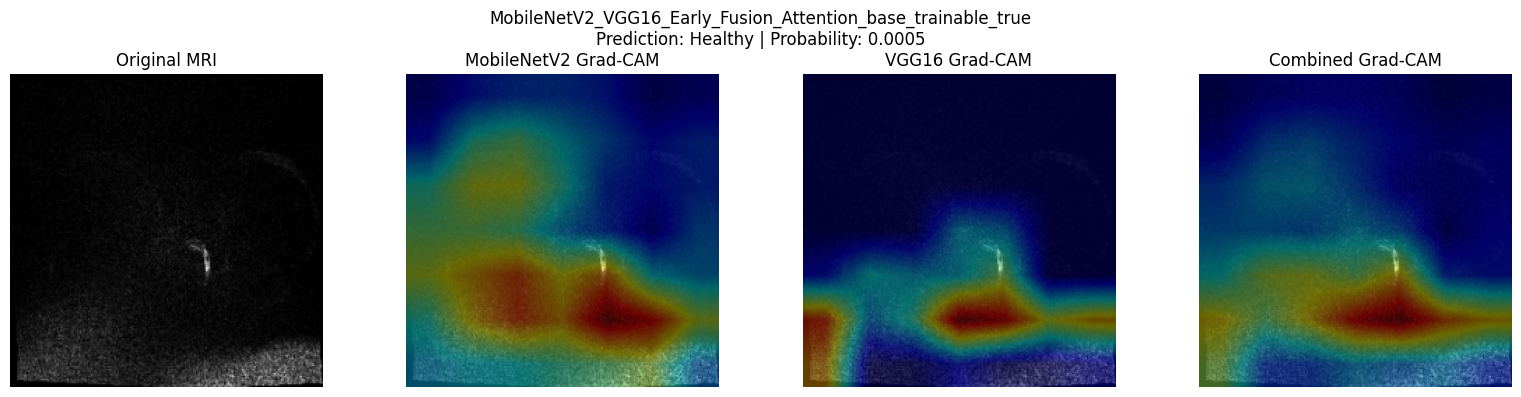

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_attention_sample_2_true_Healthy_Healthy_prob_0.0005.png


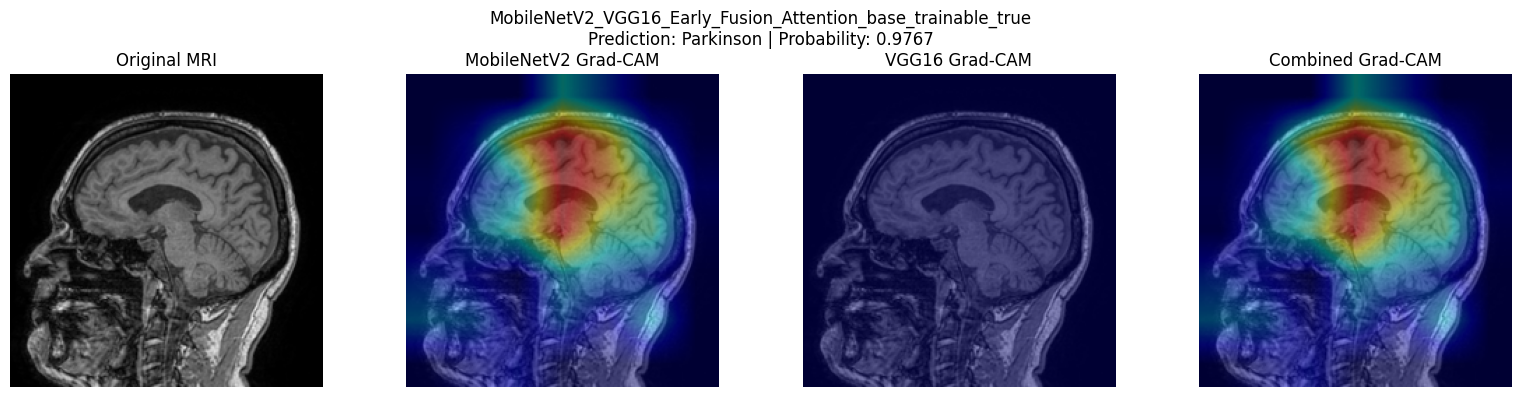

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_attention_sample_3_true_Parkinson_Parkinson_prob_0.9767.png


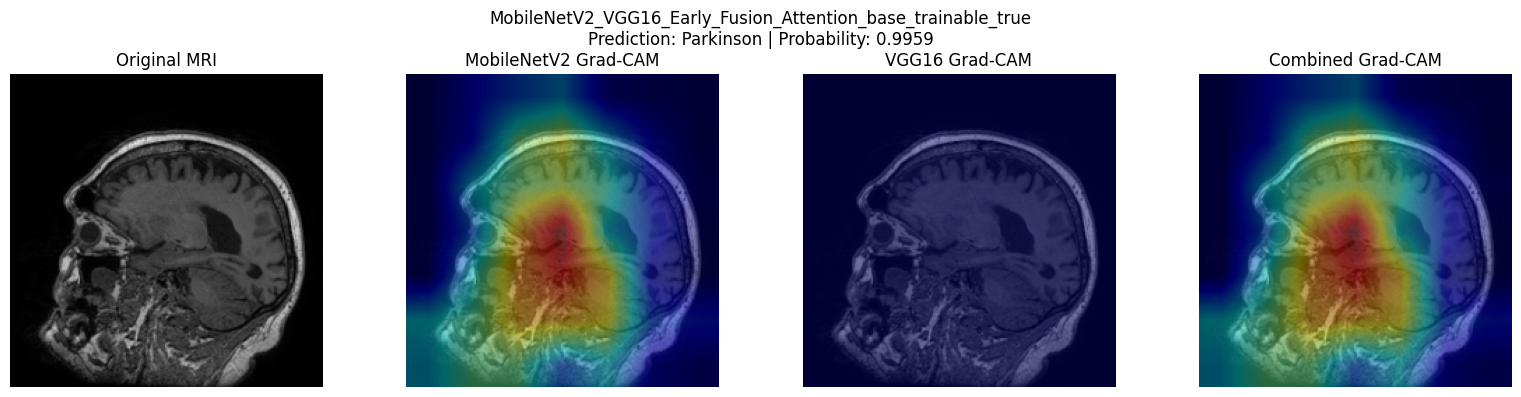

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_attention_sample_4_true_Parkinson_Parkinson_prob_0.9959.png


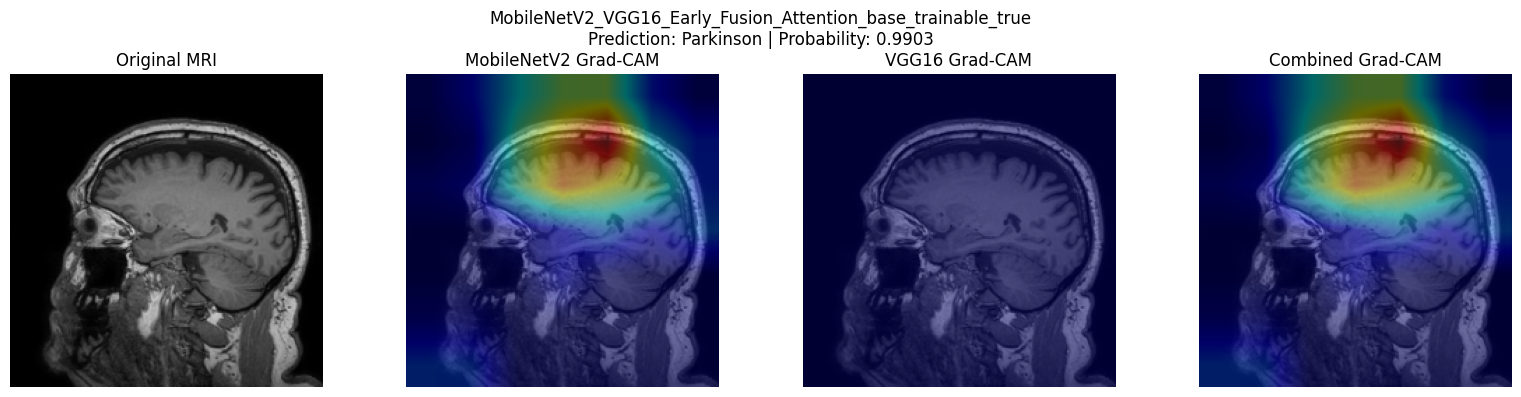

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/gradcam_heatmaps/mobilenetv2_vgg16_attention_sample_5_true_Parkinson_Parkinson_prob_0.9903.png


In [17]:
# ================================
# GENERATE GRAD-CAM FOR TEST IMAGES
# ================================

healthy_samples = test_df[test_df["label"] == "0"].sample(
    n=min(3, len(test_df[test_df["label"] == "0"])),
    random_state=42
)

parkinson_samples = test_df[test_df["label"] == "1"].sample(
    n=min(3, len(test_df[test_df["label"] == "1"])),
    random_state=42
)

gradcam_samples = pd.concat([healthy_samples, parkinson_samples]).reset_index(drop=True)

print("Grad-CAM sample images:")
print(gradcam_samples)


print("\nGenerating Grad-CAM for MobileNetV2 + VGG16 Concatenation Fusion Model...")

for idx, row in gradcam_samples.iterrows():
    image_path = row["image_path"]
    true_label = "Healthy" if row["label"] == "0" else "Parkinson"

    save_fusion_gradcam(
        model=concat_model,
        image_path=image_path,
        model_name=model_name_concat,
        save_prefix=f"mobilenetv2_vgg16_concat_sample_{idx}_true_{true_label}"
    )


print("\nGenerating Grad-CAM for MobileNetV2 + VGG16 Attention Fusion Model...")

for idx, row in gradcam_samples.iterrows():
    image_path = row["image_path"]
    true_label = "Healthy" if row["label"] == "0" else "Parkinson"

    save_fusion_gradcam(
        model=attention_model,
        image_path=image_path,
        model_name=model_name_attention,
        save_prefix=f"mobilenetv2_vgg16_attention_sample_{idx}_true_{true_label}"
    )

In [18]:
# ================================
# SAVE RAW GRAD-CAM DATA AS NPZ
# ================================
# This cell uses the existing Grad-CAM functions and saves the
# MobileNetV2, VGG16, and combined numerical heatmaps.

def save_gradcam_npz(
    model,
    image_path,
    model_name,
    save_prefix,
    true_label
):
    image = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="rgb"
    )

    display_image = keras.utils.img_to_array(
        image
    ).astype(np.float32)

    # Do not preprocess manually because preprocessing is
    # already included inside both model branches.
    image_batch = np.expand_dims(
        display_image,
        axis=0
    ).astype(np.float32)

    prediction = model.predict(
        image_batch,
        verbose=0
    ).reshape(-1)

    parkinson_probability = float(
        prediction[0]
    )

    predicted_class = int(
        parkinson_probability >= 0.5
    )

    predicted_label = (
        "Parkinson"
        if predicted_class == 1
        else "Healthy"
    )

    mobile_heatmap, _, _ = compute_branch_gradcam(
        model=model,
        img_array=image_batch,
        branch_name="mobilenetv2_backbone",
        target_class=predicted_class
    )

    vgg_heatmap, _, _ = compute_branch_gradcam(
        model=model,
        img_array=image_batch,
        branch_name="vgg16_backbone",
        target_class=predicted_class
    )

    if not np.all(np.isfinite(mobile_heatmap)):
        raise ValueError(
            "MobileNetV2 heatmap contains invalid values."
        )

    if not np.all(np.isfinite(vgg_heatmap)):
        raise ValueError(
            "VGG16 heatmap contains invalid values."
        )

    mobile_heatmap = normalize_heatmap(
        mobile_heatmap
    ).astype(np.float32)

    vgg_heatmap = normalize_heatmap(
        vgg_heatmap
    ).astype(np.float32)

    mobile_resized = cv2.resize(
        mobile_heatmap,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_LINEAR
    ).astype(np.float32)

    vgg_resized = cv2.resize(
        vgg_heatmap,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_LINEAR
    ).astype(np.float32)

    combined_heatmap = normalize_heatmap(
        (mobile_resized + vgg_resized) / 2.0
    ).astype(np.float32)

    save_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{save_prefix}_gradcam_data.npz"
    )

    np.savez_compressed(
        save_path,
        mobilenetv2_heatmap=mobile_heatmap,
        vgg16_heatmap=vgg_heatmap,
        mobilenetv2_heatmap_resized=mobile_resized,
        vgg16_heatmap_resized=vgg_resized,
        combined_heatmap=combined_heatmap,
        image_path=str(image_path),
        model_name=str(model_name),
        true_label=str(true_label),
        predicted_label=str(predicted_label),
        predicted_class=np.int32(predicted_class),
        parkinson_probability=np.float32(
            parkinson_probability
        ),
        mobilenetv2_feature_tensor=(
            "mobilenetv2_gap_input"
        ),
        vgg16_feature_tensor=(
            "vgg16_gap_input"
        )
    )

    # Verify the saved NPZ immediately.
    check = np.load(save_path)

    required_keys = {
        "mobilenetv2_heatmap",
        "vgg16_heatmap",
        "combined_heatmap",
        "parkinson_probability"
    }

    if not required_keys.issubset(
        set(check.files)
    ):
        raise ValueError(
            f"Grad-CAM NPZ keys are incomplete: "
            f"{check.files}"
        )

    print("\nGrad-CAM NPZ saved successfully")
    print("Path:", save_path)
    print("Keys:", check.files)
    print(
        "MobileNetV2 heatmap shape:",
        check["mobilenetv2_heatmap"].shape
    )
    print(
        "VGG16 heatmap shape:",
        check["vgg16_heatmap"].shape
    )
    print(
        "Combined heatmap shape:",
        check["combined_heatmap"].shape
    )
    print(
        "Parkinson probability:",
        float(check["parkinson_probability"])
    )

    return {
        "Fusion Method": model_name,
        "True Label": true_label,
        "Predicted Label": predicted_label,
        "Parkinson Probability": (
            parkinson_probability
        ),
        "Image Path": image_path,
        "NPZ Path": save_path
    }


gradcam_npz_records = []

print(
    "\nSaving Grad-CAM NPZ data for the "
    "concatenation model..."
)

for index, row in gradcam_samples.iterrows():
    image_path = row["image_path"]
    true_label = (
        "Healthy"
        if row["label"] == "0"
        else "Parkinson"
    )

    record = save_gradcam_npz(
        model=concat_model,
        image_path=image_path,
        model_name=model_name_concat,
        save_prefix=(
            f"mobilenetv2_vgg16_concat_"
            f"sample_{index}_true_{true_label}"
        ),
        true_label=true_label
    )

    gradcam_npz_records.append(record)


print(
    "\nSaving Grad-CAM NPZ data for the "
    "attention model..."
)

for index, row in gradcam_samples.iterrows():
    image_path = row["image_path"]
    true_label = (
        "Healthy"
        if row["label"] == "0"
        else "Parkinson"
    )

    record = save_gradcam_npz(
        model=attention_model,
        image_path=image_path,
        model_name=model_name_attention,
        save_prefix=(
            f"mobilenetv2_vgg16_attention_"
            f"sample_{index}_true_{true_label}"
        ),
        true_label=true_label
    )

    gradcam_npz_records.append(record)


gradcam_npz_summary_df = pd.DataFrame(
    gradcam_npz_records
)

gradcam_npz_summary_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_mobilenet_early_fusion_"
    "gradcam_npz_summary.csv"
)

gradcam_npz_summary_df.to_csv(
    gradcam_npz_summary_path,
    index=False
)

print(
    "\nGrad-CAM NPZ summary saved:",
    gradcam_npz_summary_path
)

display(gradcam_npz_summary_df)



Saving Grad-CAM NPZ data for the concatenation model...

Grad-CAM NPZ saved successfully
Path: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/mobilenetv2_vgg16_concat_sample_0_true_Healthy_gradcam_data.npz
Keys: ['mobilenetv2_heatmap', 'vgg16_heatmap', 'mobilenetv2_heatmap_resized', 'vgg16_heatmap_resized', 'combined_heatmap', 'image_path', 'model_name', 'true_label', 'predicted_label', 'predicted_class', 'parkinson_probability', 'mobilenetv2_feature_tensor', 'vgg16_feature_tensor']
MobileNetV2 heatmap shape: (7, 7)
VGG16 heatmap shape: (7, 7)
Combined heatmap shape: (224, 224)
Parkinson probability: 0.4424959421157837

Grad-CAM NPZ saved successfully
Path: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/mobilenetv2_vgg16_concat_sample_1_true_Healthy_gradcam_data.npz
Keys: ['mobilenetv2_heatmap', 'vgg16_heatmap', 'mobilenetv2_heatmap_resized', 'vgg16_heatmap_resized', 'combined_heatmap', 'image_path', 'model_name', 'true_label', 'predicted_

,Fusion Method,True Label,Predicted Label,Parkinson Probability,Image Path,NPZ Path
0,MobileNetV2_VGG16_Early_Fusion_Concatenation_b...,Healthy,Healthy,0.442496,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
1,MobileNetV2_VGG16_Early_Fusion_Concatenation_b...,Healthy,Healthy,0.467957,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
2,MobileNetV2_VGG16_Early_Fusion_Concatenation_b...,Healthy,Healthy,0.388277,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
3,MobileNetV2_VGG16_Early_Fusion_Concatenation_b...,Parkinson,Parkinson,0.625652,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
4,MobileNetV2_VGG16_Early_Fusion_Concatenation_b...,Parkinson,Parkinson,0.993772,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
5,MobileNetV2_VGG16_Early_Fusion_Concatenation_b...,Parkinson,Parkinson,0.953825,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
6,MobileNetV2_VGG16_Early_Fusion_Attention_base_...,Healthy,Healthy,0.030291,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
7,MobileNetV2_VGG16_Early_Fusion_Attention_base_...,Healthy,Healthy,0.187023,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
8,MobileNetV2_VGG16_Early_Fusion_Attention_base_...,Healthy,Healthy,0.000499,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...
9,MobileNetV2_VGG16_Early_Fusion_Attention_base_...,Parkinson,Parkinson,0.976667,/content/drive/MyDrive/Colab Notebooks/Mobilen...,/content/drive/MyDrive/Colab Notebooks/Mobilen...


In [19]:
# ================================
# CHECK SAVED OUTPUTS
# ================================

print("Models saved in:", MODEL_DIR)
print(os.listdir(MODEL_DIR))

print("\nGraphs saved in:", GRAPH_DIR)
print(os.listdir(GRAPH_DIR))

print("\nConfusion matrices saved in:", CM_DIR)
print(os.listdir(CM_DIR))

print("\nReports saved in:", REPORT_DIR)
print(os.listdir(REPORT_DIR))

print("\nHistory files saved in:", HISTORY_DIR)
print(os.listdir(HISTORY_DIR))

print("\nGrad-CAM heatmaps saved in:", GRADCAM_DIR)
print(os.listdir(GRADCAM_DIR))

Models saved in: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/models
['MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_best.keras', 'MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_final.keras', 'MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_best.keras', 'MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_final.keras']

Graphs saved in: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/graphs
['MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_accuracy_vs_epochs.png', 'MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_loss_vs_epochs.png', 'MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_auc_vs_epochs.png', 'MobileNetV2_VGG16_Early_Fusion_Concatenation_base_trainable_true_roc_curve.png', 'MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_accuracy_vs_epochs.png', 'MobileNetV2_VGG16_Early_Fusion_Attention_base_trainable_true_loss

In [20]:
# ================================
# VERIFY ALL NPZ FILES
# ================================
npz_files = sorted(
    glob.glob(
        os.path.join(
            ROOT_OUTPUT_DIR,
            "*.npz"
        )
    )
)

verification_records = []

for npz_path in npz_files:
    try:
        data = np.load(npz_path)

        verification_records.append({
            "Filename": os.path.basename(
                npz_path
            ),
            "Full Path": npz_path,
            "Keys": ", ".join(data.files),
            "File Size Bytes": os.path.getsize(
                npz_path
            ),
            "Loads Successfully": True
        })

    except Exception as error:
        verification_records.append({
            "Filename": os.path.basename(
                npz_path
            ),
            "Full Path": npz_path,
            "Keys": "",
            "File Size Bytes": (
                os.path.getsize(npz_path)
                if os.path.exists(npz_path)
                else 0
            ),
            "Loads Successfully": False,
            "Error": repr(error)
        })

npz_verification_df = pd.DataFrame(
    verification_records
)

display(npz_verification_df)

verification_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_mobilenet_npz_verification.csv"
)

npz_verification_df.to_csv(
    verification_path,
    index=False
)

print("NPZ files saved in:", ROOT_OUTPUT_DIR)
print("Verification CSV:", verification_path)

required_roc_files = [
    "vgg16_mobilenet_early_fusion_"
    "concatenation_roc_data.npz",

    "vgg16_mobilenet_early_fusion_"
    "attention_roc_data.npz",

    "vgg16_mobilenet_early_fusion_"
    "roc_data.npz"
]

for required_file in required_roc_files:
    required_path = os.path.join(
        ROOT_OUTPUT_DIR,
        required_file
    )

    print(
        required_file,
        "exists:",
        os.path.exists(required_path)
    )


,Filename,Full Path,Keys,File Size Bytes,Loads Successfully
0,mobilenetv2_vgg16_attention_sample_0_true_Heal...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",395193,True
1,mobilenetv2_vgg16_attention_sample_1_true_Heal...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",360555,True
2,mobilenetv2_vgg16_attention_sample_2_true_Heal...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",342490,True
3,mobilenetv2_vgg16_attention_sample_3_true_Park...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",271539,True
4,mobilenetv2_vgg16_attention_sample_4_true_Park...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",274841,True
5,mobilenetv2_vgg16_attention_sample_5_true_Park...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",227353,True
6,mobilenetv2_vgg16_concat_sample_0_true_Healthy...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",253008,True
7,mobilenetv2_vgg16_concat_sample_1_true_Healthy...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",164700,True
8,mobilenetv2_vgg16_concat_sample_2_true_Healthy...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",183785,True
9,mobilenetv2_vgg16_concat_sample_3_true_Parkins...,/content/drive/MyDrive/Colab Notebooks/Mobilen...,"mobilenetv2_heatmap, vgg16_heatmap, mobilenetv...",365512,True


NPZ files saved in: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here
Verification CSV: /content/drive/MyDrive/Colab Notebooks/Mobilenet_vgg16_data_save_here/vgg16_mobilenet_npz_verification.csv
vgg16_mobilenet_early_fusion_concatenation_roc_data.npz exists: True
vgg16_mobilenet_early_fusion_attention_roc_data.npz exists: True
vgg16_mobilenet_early_fusion_roc_data.npz exists: True


## Added NPZ outputs

"
        "The notebook now saves ROC probabilities for concatenation, "
        "attention, and the automatically selected best fusion model. "
        "It also saves the raw MobileNetV2, VGG16, and combined Grad-CAM "
        "heatmaps as compressed NPZ files in "
        "`/content/drive/MyDrive/ROC_DATA/`.